In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from link_prediction.config import (
    RESULTS_DIR,
)
from link_prediction.statistical_analysis import (
    load_benchmark_fold_metrics,
)
from link_prediction.tie_analysis import (
    run_tie_analysis,
)

In [2]:
benchmark_name = "standard"

figure_directory = (
    RESULTS_DIR
    / "figures"
    / benchmark_name
)

figure_directory.mkdir(
    parents=True,
    exist_ok=True,
)

fold_metrics = (
    load_benchmark_fold_metrics(
        benchmark_name=
            benchmark_name,
    )
)

tie_results = run_tie_analysis(
    fold_metrics=
        fold_metrics,
    benchmark_name=
        benchmark_name,
)

network_ties = tie_results[
    "network_ties"
]

method_ties = tie_results[
    "method_ties"
]

In [3]:
method_ties[
    [
        "method",
        "analysis_family",
        "network_count",
        "mean_tied_candidate_ratio",
        "mean_cutoff_tie_size",
        "mean_cutoff_boundary_tie_rate",
    ]
].sort_values(
    [
        "mean_cutoff_boundary_tie_rate",
        "mean_tied_candidate_ratio",
        "method",
    ],
    ascending=[
        False,
        False,
        True,
    ],
).reset_index(
    drop=True
)

,method,analysis_family,network_count,mean_tied_candidate_ratio,mean_cutoff_tie_size,mean_cutoff_boundary_tie_rate
0,CN,standard_local,8,0.998601,1192.075,1.000
1,CAR-CN,enhanced_local,8,0.950278,1271.700,1.000
2,HDI,standard_local,8,0.963565,917.700,0.975
3,HPI,standard_local,8,0.977859,930.325,0.925
4,JA,standard_local,8,0.940550,914.750,0.925
5,SO,standard_local,8,0.940550,914.750,0.925
6,FSW,enhanced_local,8,0.802265,914.125,0.900
7,PA,standard_local,8,0.940246,38.225,0.875
8,LLHN,standard_local,8,0.836698,909.100,0.800
9,LPI-beta-0.001,quasi_local_path,8,0.822322,684.675,0.775


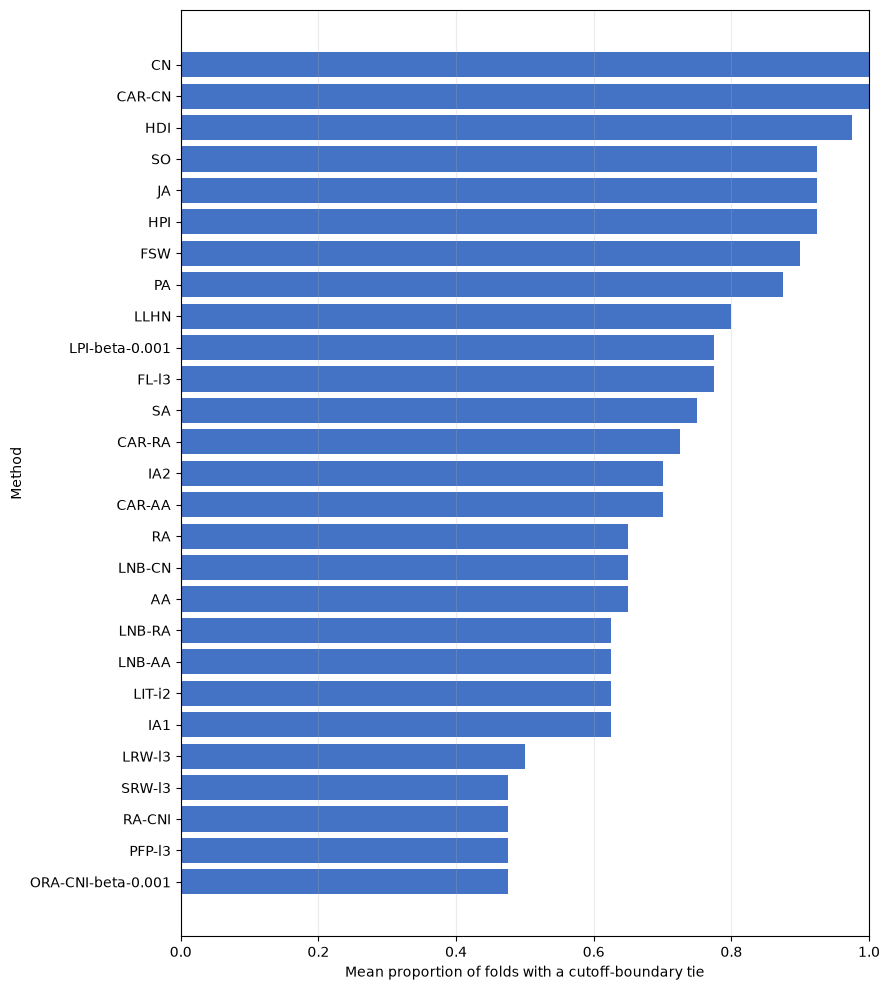

In [4]:
method_plot = (
    method_ties
    .sort_values(
        [
            "mean_cutoff_boundary_tie_rate",
            "method",
        ]
    )
)

figure, axis = plt.subplots(
    figsize=(
        9,
        10,
    )
)

axis.barh(
    method_plot[
        "method"
    ],
    method_plot[
        "mean_cutoff_boundary_tie_rate"
    ],
    color="#4472C4",
)

axis.set_xlabel(
    "Mean proportion of folds with a cutoff-boundary tie"
)

axis.set_ylabel(
    "Method"
)

axis.set_xlim(
    0.0,
    1.0,
)

axis.grid(
    axis="x",
    alpha=0.25,
)

figure.tight_layout()

figure.savefig(
    figure_directory
    / "method_cutoff_tie_rate.png",
    dpi=300,
    bbox_inches="tight",
)

figure.savefig(
    figure_directory
    / "method_cutoff_tie_rate.pdf",
    bbox_inches="tight",
)

plt.show()

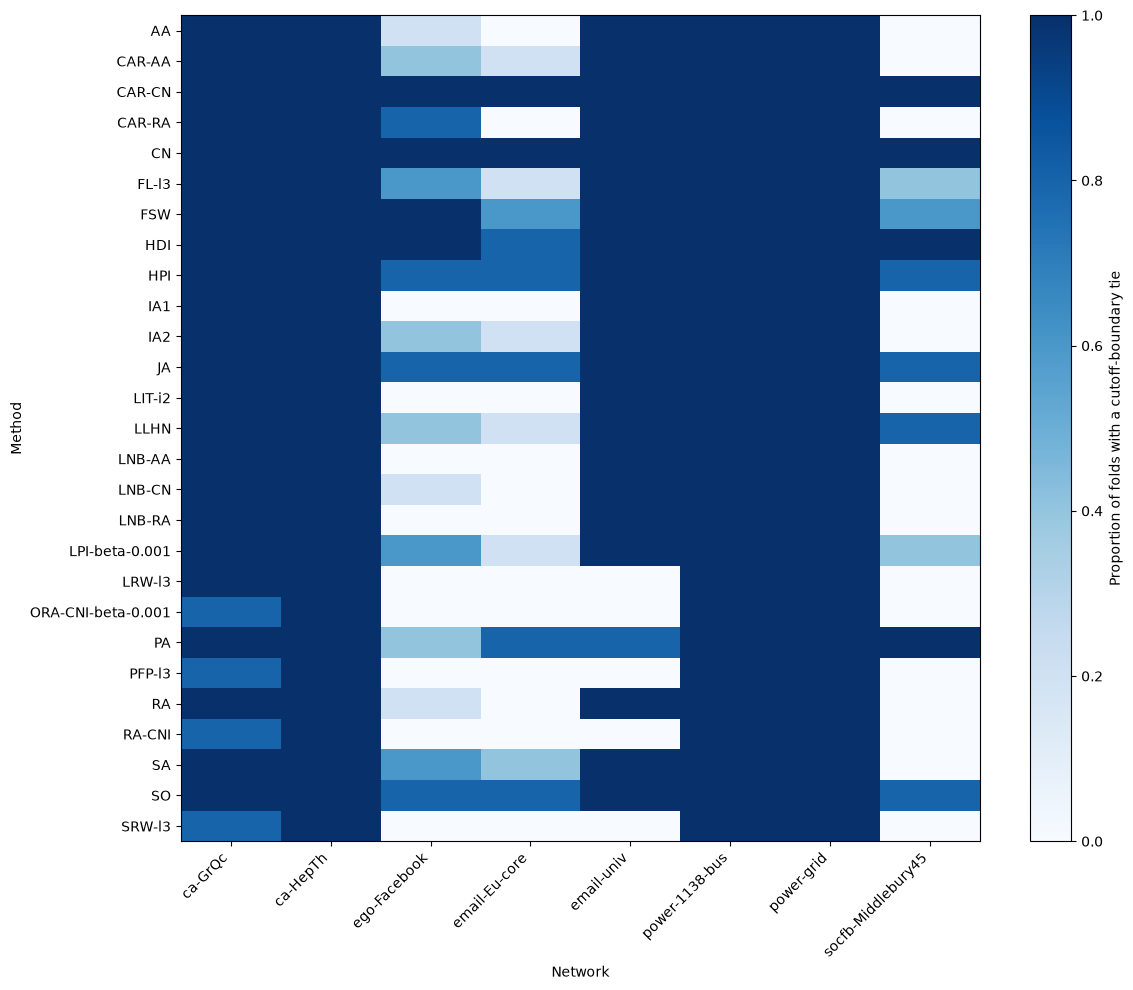

In [5]:
tie_matrix = (
    network_ties
    .pivot(
        index="method",
        columns="network",
        values="cutoff_boundary_tie_rate",
    )
    .sort_index()
)

figure, axis = plt.subplots(
    figsize=(
        12,
        10,
    )
)

image = axis.imshow(
    tie_matrix.to_numpy(),
    aspect="auto",
    cmap="Blues",
    vmin=0.0,
    vmax=1.0,
)

axis.set_xticks(
    range(
        len(
            tie_matrix.columns
        )
    )
)

axis.set_xticklabels(
    tie_matrix.columns,
    rotation=45,
    ha="right",
)

axis.set_yticks(
    range(
        len(
            tie_matrix.index
        )
    )
)

axis.set_yticklabels(
    tie_matrix.index,
)

axis.set_xlabel(
    "Network"
)

axis.set_ylabel(
    "Method"
)

colorbar = figure.colorbar(
    image,
    ax=axis,
)

colorbar.set_label(
    "Proportion of folds with a cutoff-boundary tie"
)

figure.tight_layout()

figure.savefig(
    figure_directory
    / "network_method_cutoff_tie_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

figure.savefig(
    figure_directory
    / "network_method_cutoff_tie_heatmap.pdf",
    bbox_inches="tight",
)

plt.show()

In [6]:
network_ties[
    [
        "network",
        "method",
        "analysis_family",
        "mean_tied_candidate_ratio",
        "mean_largest_tie_group",
        "mean_cutoff_tie_size",
        "cutoff_boundary_tie_count",
        "cutoff_boundary_tie_rate",
    ]
].sort_values(
    [
        "network",
        "cutoff_boundary_tie_rate",
        "mean_tied_candidate_ratio",
        "method",
    ],
    ascending=[
        True,
        False,
        False,
        True,
    ],
).reset_index(
    drop=True
)

,network,method,analysis_family,mean_tied_candidate_ratio,mean_largest_tie_group,mean_cutoff_tie_size,cutoff_boundary_tie_count,cutoff_boundary_tie_rate
0,ca-GrQc,CN,standard_local,0.999784,1964.0,1964.0,5,1.0
1,ca-GrQc,HPI,standard_local,0.979223,1964.0,1964.0,5,1.0
2,ca-GrQc,HDI,standard_local,0.960496,1964.0,1964.0,5,1.0
3,ca-GrQc,PA,standard_local,0.948786,198.2,47.4,5,1.0
4,ca-GrQc,JA,standard_local,0.939072,1964.0,1964.0,5,1.0
...,...,...,...,...,...,...,...,...
211,socfb-Middlebury45,RA-CNI,enhanced_local,0.046318,1942.6,1.0,0,0.0
212,socfb-Middlebury45,ORA-CNI-beta-0.001,quasi_local_path,0.045956,1937.2,1.0,0,0.0
213,socfb-Middlebury45,LRW-l3,quasi_local_walk,0.044928,1940.4,1.0,0,0.0
214,socfb-Middlebury45,SRW-l3,quasi_local_walk,0.044842,1937.2,1.0,0,0.0
